### myPortfolioManagement Package (Portfolio Optimisation) 

 - Routine to download data 
 - Routine to quickly see correlations ( linear, non-linear - at tails ) 
 - Routine to quickly Generate HRP portfolio with a range of risk measure objectives, linkages and constraints  

In [1]:
%reset -f
import warnings
warnings.filterwarnings('ignore')

# for interactive 
from itables import init_notebook_mode
init_notebook_mode(all_interactive = True)
import itables.options as opt
opt.maxBytes = 2**20
opt.maxColumns= 0

import pandas as pd 
#pd.options.display.float_format = '{:.2%}'.format

import numpy as np
from os import path 

import pyfolio as pf

import pypfopt
from pypfopt import expected_returns
from pypfopt import plotting
import ffn

import riskfolio as rp
from datetime import date, timedelta

import seaborn as sns
import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

In [2]:
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [46]:
from myPortfolioManagement.myPortfolioOptimisation import equal_weight_portfolio,generate_HRP_portfolios, inverse_vol_portfolio, generate_rp_portfolios
from myPortfolioManagement.myReturns import calculate_portfolio_returns
from myPortfolioManagement.myPerformanceAnalytics import ranking_metrics
from myPortfolioManagement.myBacktesting import backtest_report

In [4]:
# import list of funds 
mypath    = '/Users/safishajjouz/GitHub/QuantitativePortfolioManagement/myPortfolioManagement/Data'

# denoised returns 
file_name = "returns_sample.csv"
file_path_to_load = path.join(mypath, file_name)
ret = pd.read_csv(file_path_to_load)
ret['Date'] = pd.to_datetime(ret['Date'])
ret = ret.set_index('Date')
ret.head()

Loading... (need help?)


In [5]:
## Portfolio Optimisation 

myassets = ['Scottish Mortgage Ord',                # Global Equity (focus on long-term) 
            'Invesco EQQQ NASDAQ-100 ETF GBP',      # Tech 
            'Rathbone Global Opportunities S Acc',  # Flex Global Cap 
            'Stewart Inv APAC Ldrs Sstby B GBP Acc', # Pacific Specialist 
            'BlackRock Throgmorton Trust Ord',       # UK small Cap 
            'HarbourVest Global Priv Equity Ord',    # Alternative 
            'Janus Henderson Mlt-Ast AbsRet I Acc']  # Absolute Alpha (proxy for JPM's fund due to missing data)

### Training Period 

training_start_date = '2018-01-01'
trainsing_end_date  = '2020-01-01'

ret_training = ret[myassets]
ret_training = ret_training[(ret_training.index>=training_start_date) & (ret_training.index<=trainsing_end_date)]
ret_training

Loading... (need help?)


In [6]:
### Naive Allocation 
df_naive = equal_weight_portfolio(ret_training, my_assets_col_name='fund')
df_naive

Loading... (need help?)


In [9]:
df_inverse_vol = inverse_vol_portfolio(ret_training, my_assets_col_name='fund')
df_inverse_vol

Loading... (need help?)


In [10]:
### Inverse Volatility
df_inverse_vol.index = df_inverse_vol.index.set_names(['fund'] )
df_inverse_vol = df_inverse_vol.reset_index()
df_all_weights = df_inverse_vol.merge(df_naive, on = 'fund')
df_all_weights

Loading... (need help?)


In [14]:
### Risk Parity 
df_rp = generate_rp_portfolios(ret_training, risk_measure='MSV')     

In [15]:
df_rp.index = df_rp.index.set_names(['fund'])
df_rp = df_rp.reset_index()

df_all_weights = df_all_weights.merge(df_rp, on = 'fund')
df_all_weights

Loading... (need help?)


### De Prado's Hierarchical 

HERC and other extensions don;t work currently with constraints (To do: filter them out)

In [19]:
df_HRP_portfolios = generate_HRP_portfolios(returns = ret_training.dropna(), 
                            weight_max = 0.40,
                            weight_min = 0.05,
                            rf = 0.01)

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

W Matrix too small 

generate_HRP_portfolios took 82.916sec


In [20]:
df_HRP_portfolios.index = df_HRP_portfolios.index.set_names(['fund'])
df_HRP_portfolios = df_HRP_portfolios.reset_index()
df_all_weights = df_all_weights.merge(df_HRP_portfolios, on = 'fund')
df_all_weights

Loading... (need help?)


In [21]:
df_all_weights = df_all_weights.set_index('fund')

In [26]:
df_portfolio_returns = []
for col in df_all_weights.columns:
    temp =  calculate_portfolio_returns(ret, 
                                myassets_list = list(df_all_weights.index),
                                myweights_list= df_all_weights[col],
                                portfolio_name = col)
    df_portfolio_returns.append(temp)

df_portfolio_returns = pd.concat(df_portfolio_returns, axis = 1)

In [27]:
df_portfolio_returns

Loading... (need help?)


### in-sample returns 

To do: 
- Train in the model in the full sample and leave out recent months / year to check out-of-sample 
- Check under different market regimes 
- Train the model and check it against "unseen" regime 
- Train the model between 2020-01 till 20-03-01 (reason is this period good proxy for condensing "100 years" of history ( tail risk due to pandemic, rise and fall of crash of tech stocks, rise of commodities, recession-recovery, rising inflation and yields, boom and bust of China etc -- note: missing QE tapering and interest rates shocks. Accommodate this with stress-testing checks. ) 


df_all_weights = df_all_weights.set_index('fund')
df_portfolio_returns = pd.DataFrame([])
for portfolio_name in list(df_all_weights.columns):
    temp = culculate_portfolio_returns(ret,
                                       df_all_weights.index.to_list(),
                                       df_all_weights[portfolio_name].to_list(), 
                                       portfolio_name = portfolio_name)
    df_portfolio_returns = pd.concat([df_portfolio_returns, temp], axis=1)

df_portfolio_returns

In [28]:
# check some basic perfomance stats for each asset 
price_index = ffn.core.to_price_index(df_portfolio_returns, start=100)
df_stats = ffn.core.GroupStats(price_index).stats
df_stats = df_stats.transpose().drop(['start', 'end', 'rf'], axis = 1)
df_stats

Loading... (need help?)


In [29]:
### Merge Portfolio returns 
ret_all = df_portfolio_returns.reset_index().merge(ret.reset_index(), on= 'Date')

In [30]:
ret_all = ret_all.set_index('Date')

In [31]:
price_index = ffn.core.to_price_index(ret_all, start=100)

In [32]:
price_index

Loading... (need help?)


In [33]:
df_all_prices = pd.melt(price_index.reset_index(), id_vars = 'Date',value_name = 'price', var_name = 'fund')

In [37]:
# choose benchmark
bench = ['Vanguard FTSE Dev Wld ex-UK Eq Idx £ Acc', 
         'iShares Core S&P 500 ETF USD Acc GBP',
        'Invesco EQQQ NASDAQ-100 ETF GBP'][2]


rolling_window     = 5
rolling_frequency  = 'Y'
my_assets_col_name = 'fund' 
my_date_col_name   = 'Date'
price_col_name = 'price'
benchmark_name = bench

df_reward_metrics = ranking_metrics(df = df_all_prices, 
                                   rolling_window = rolling_window, 
                                   rolling_frequency = rolling_frequency,
                                   my_assets_col_name = my_assets_col_name, 
                                   my_date_col_name = my_date_col_name,
                                   price_col_name = price_col_name,
                                   benchmark_name = benchmark_name)
df_reward_metrics

Loading... (need help?)


In [40]:
df_all_weights['por_rp_MSV']

Loading... (need help?)


<AxesSubplot:xlabel='Date'>

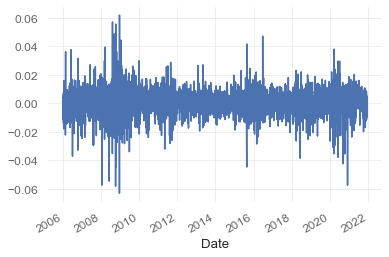

In [59]:
df_portfolio_returns['por_rp_MSV'].plot()

In [58]:
import quantstats as qs
qs.reports.metrics(df_portfolio_returns['por_rp_MSV'][df_portfolio_returns.index>='2020-10-28'], mode='full')

                           Strategy
-------------------------  ----------
Start Period               2020-11-02
End Period                 2021-11-30
Risk-Free Rate             0.0%
Time in Market             99.0%

Cumulative Return          21.26%
CAGR﹪                     19.61%

Sharpe                     1.49
Smart Sharpe               1.45
Sortino                    2.0
Smart Sortino              1.96
Sortino/√2                 1.42
Smart Sortino/√2           1.39
Omega                      1.31

Max Drawdown               -8.14%
Longest DD Days            333
Volatility (ann.)          12.55%
Calmar                     2.41
Skew                       -1.65
Kurtosis                   10.47

Expected Daily %           0.07%
Expected Monthly %         1.29%
Expected Yearly %          10.12%
Kelly Criterion            14.21%
Risk of Ruin               0.0%
Daily Value-at-Risk        -1.23%
Expected Shortfall (cVaR)  -1.23%

Gain/Pain Ratio            0.31
Gain/Pain (1M)             